# Monte Carlo Rollout: SOC Trajectories
Mean and variance of N rollouts of a trained RL policy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Parameters ──────────────────────────────────────────────────────────────
N_ROLLOUTS   = 100         # number of Monte Carlo rollouts
EPISODE_LEN  = 288         # timesteps (288 × 5 min = 24 h)
CONTROL_STEP = 300         # seconds per step
RNG_SEED     = 42

rng = np.random.default_rng(RNG_SEED)
time_hours = np.arange(EPISODE_LEN) * CONTROL_STEP / 3600  # x-axis in hours

# ── Generate dummy SOC trajectories ─────────────────────────────────────────
def baseline_soc(t):
    """
    SOC curve shape:
      0 – 6h   : slight rise        (~0.56 → 0.60)
      6 – 8.5h : dip                (~0.60 → 0.47)
      8.5–15.5h: strong rise        (~0.47 → 0.79)
      15.5–23h : long drop          (~0.79 → 0.47)
      23–24h   : recharge           (~0.47 → 0.57)
    """
    h = t / EPISODE_LEN * 24  # map timestep index → hour of day [0, 24)

    def sig(x, center, k):
        return 1.0 / (1.0 + np.exp(-k * (x - center)))

    slight_morning_rise =  0.08 * sig(h,  3.0,  0.8)   # gentle rise  0→6h
    midmorning_dip      = -0.20 * sig(h,  7.25, 1.5)   # dip          6→8.5h
    daytime_rise        =  0.40 * sig(h, 12.0,  0.9)   # strong rise  8.5→15.5h
    afternoon_drop      = -0.40 * sig(h, 19.0,  0.75)  # long drop    15.5→23h
    night_rise          =  0.1 * sig(h, 23.5,  4.0)    # recharge     after 23h
    
    soc_sum = slight_morning_rise + midmorning_dip + daytime_rise + afternoon_drop + night_rise
    return np.clip(0.55 + soc_sum, 0.0, 1.0)

t_idx = np.arange(EPISODE_LEN)
mean_baseline = baseline_soc(t_idx)

# Amplitude grows linearly: narrow band at t=0, wider band at t=T.
# This reflects how small initial differences compound over an RL episode.
amplitude = np.linspace(0.01, 0.075, EPISODE_LEN)

trajectories = np.zeros((N_ROLLOUTS, EPISODE_LEN))
for i in range(N_ROLLOUTS):
    # AR(1) correlated unit noise (temporal smoothness)
    unit_noise = rng.normal(0, 1, size=EPISODE_LEN)
    for t in range(1, EPISODE_LEN):
        unit_noise[t] = 0.7 * unit_noise[t - 1] + 0.3 * unit_noise[t]
    # Normalise to unit std, then apply growing amplitude
    unit_noise /= unit_noise.std() + 1e-8
    noise = unit_noise * amplitude
    trajectories[i] = np.clip(mean_baseline + noise, 0.0, 1.0)

mean_traj = trajectories.mean(axis=0)
std_traj  = trajectories.std(axis=0)

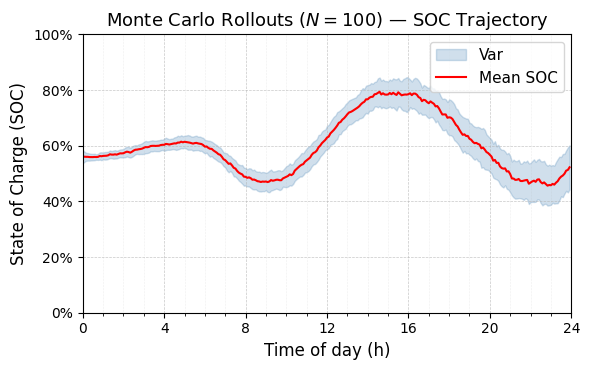

In [4]:
# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.8))

ax.fill_between(
    time_hours,
    mean_traj - std_traj,
    mean_traj + std_traj,
    alpha=0.25,
    color='steelblue',
    label=r'Var',
)
ax.plot(time_hours, mean_traj, color='red', linewidth=1.5, label='Mean SOC')

ax.set_xlabel('Time of day (h)', fontsize=12)
ax.set_ylabel('State of Charge (SOC)', fontsize=12)
ax.set_title(f'Monte Carlo Rollouts ($N={N_ROLLOUTS}$) — SOC Trajectory', fontsize=13)

ax.set_xlim(0, 24)
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(True, which='minor', linestyle=':',  linewidth=0.4, alpha=0.4)

ax.legend(fontsize=11)
fig.tight_layout()
plt.savefig('out/dummy_mc_rollout_soc.pdf', bbox_inches='tight')
plt.savefig("out/dummy_mc_rollout_soc.svg")
plt.show()